In [ ]:
import subprocess
gpu = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(gpu.stdout if gpu.returncode == 0 else 'No GPU!')
import torch
print('CUDA:', torch.cuda.is_available(), '| Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Sat May  9 18:00:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q ultralytics
import ultralytics; ultralytics.checks()

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)


In [3]:
import os

BASE     = '/kaggle/input/datasets/snvngc11/signal/data_sig'
WORK_DIR = '/kaggle/working'
RUN_NAME = 'signal_seg_v6'

for split in ['train', 'val']:
    imgs = os.listdir(f'{BASE}/images/{split}')
    lbls = os.listdir(f'{BASE}/labels/{split}')
    print(f'{split}: {len(imgs)} images, {len(lbls)} labels')

train: 185 images, 185 labels
val: 47 images, 47 labels


In [ ]:
label_dir = f'{BASE}/labels/train'
sample    = os.listdir(label_dir)[0]
print('File:', sample)
with open(f'{label_dir}/{sample}') as f:
    print(f.read()[:300])

File: video4_f000728.txt
0 0.4234375 0.7555555555555555 0.4171875 0.7555555555555555 0.415625 0.7583333333333333 0.4125 0.7583333333333333 0.4109375 0.7611111111111111 0.409375 0.7611111111111111 0.4078125 0.7638888888888888 0.40625 0.7638888888888888 0.403125 0.7694444444444445 0.4015625 0.7694444444444445 0.4 0.7722222222


In [ ]:
import shutil, yaml

src_yaml  = f'{BASE}/data.yaml'
DATA_YAML = f'{WORK_DIR}/data.yaml'

shutil.copy(src_yaml, DATA_YAML)

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

cfg['path']  = BASE
cfg['train'] = 'images/train'
cfg['val']   = 'images/val'
cfg['nc']    = 1
cfg['names'] = ['signal']

with open(DATA_YAML, 'w') as f:
    yaml.dump(cfg, f)

print('data.yaml patched:', cfg)

data.yaml patched: {'train': 'images/train', 'val': 'images/val', 'nc': 1, 'names': ['signal'], 'path': '/kaggle/input/datasets/snvngc11/signal/data_sig'}


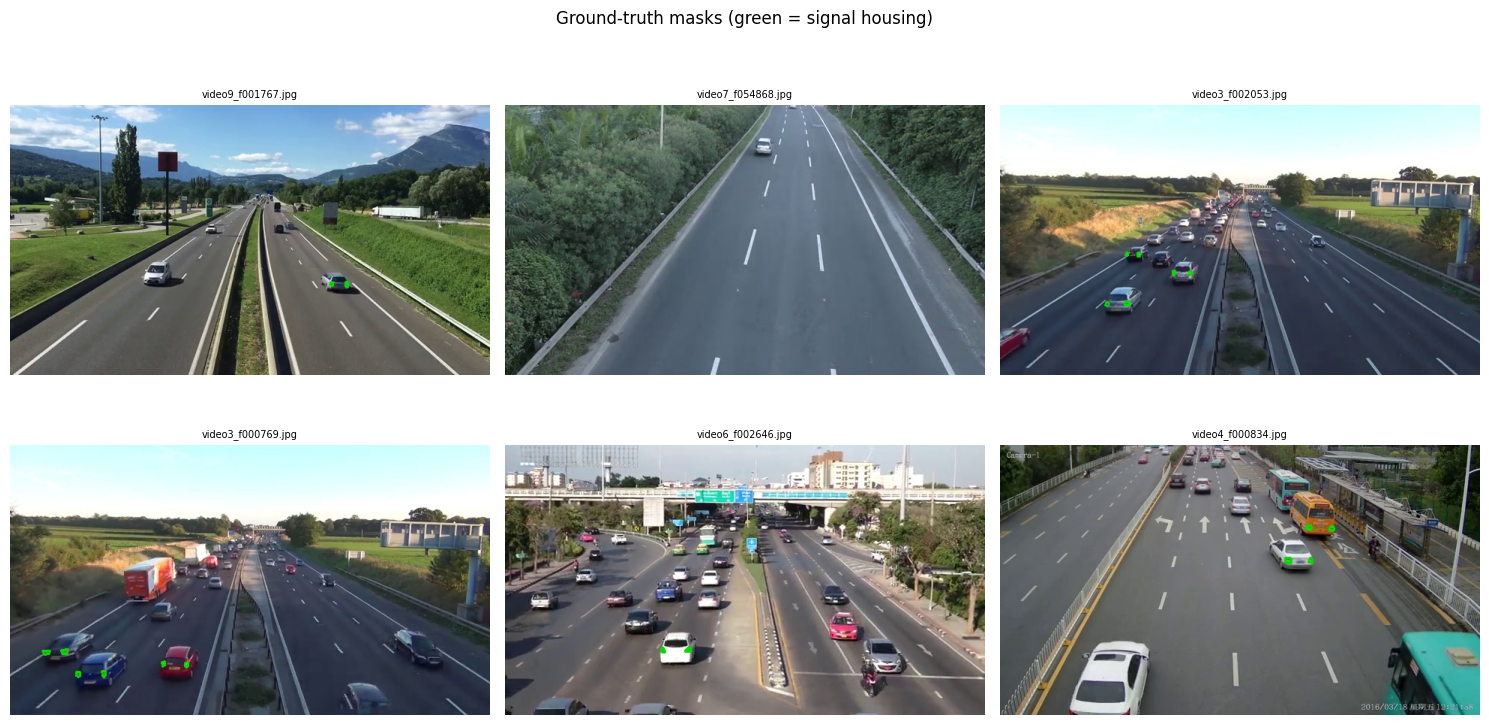

In [ ]:
import cv2, numpy as np, random, matplotlib.pyplot as plt
from pathlib import Path

def draw_seg_labels(img_path, lbl_path):
    img = cv2.imread(str(img_path))
    if img is None: return None
    h, w = img.shape[:2]
    lbl = Path(lbl_path)
    if lbl.exists():
        for line in lbl.read_text().strip().split('\n'):
            if not line.strip(): continue
            parts = list(map(float, line.split()))
            pts   = np.array(parts[1:]).reshape(-1, 2)
            pts[:, 0] *= w; pts[:, 1] *= h
            pts     = pts.astype(np.int32)
            overlay = img.copy()
            cv2.fillPoly(overlay, [pts], (0, 255, 0))
            img = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)
            cv2.polylines(img, [pts], True, (0, 220, 0), 2)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_dir  = f'{BASE}/images/train'
lbl_dir  = f'{BASE}/labels/train'
all_imgs = os.listdir(img_dir)
samples  = random.sample(all_imgs, min(6, len(all_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, fname in zip(axes.flat, samples):
    stem = Path(fname).stem
    vis  = draw_seg_labels(f'{img_dir}/{fname}', f'{lbl_dir}/{stem}.txt')
    if vis is not None:
        ax.imshow(vis); ax.set_title(fname, fontsize=7)
    ax.axis('off')

plt.suptitle('Ground-truth masks (green = signal housing)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/gt_samples.png', dpi=100)
plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO(f'{WORK_DIR}/runs/segment/{RUN_NAME}/weights/last.pt')

results = model.train(
    data          = DATA_YAML,
    epochs        = 130,         
    imgsz         = 1280,
    batch         = 8,
    device        = 0,
    project       = f'{WORK_DIR}/runs/segment',
    name          = RUN_NAME,
    exist_ok      = True,
    resume        = True,      
    patience      = 50,         
)

WARNING ⚠️ model '/kaggle/working/runs/segment/signal_seg_v6/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=130, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0

In [14]:
from ultralytics import YOLO

best_pt   = f'{WORK_DIR}/runs/segment/{RUN_NAME}/weights/best.pt'
model_val = YOLO(best_pt)

val_results = model_val.val(
    data      = DATA_YAML,
    imgsz     = 1280,
    conf      = 0.25,
    iou       = 0.6,
    device    = 0,
    split     = 'val',
    plots     = True,
    save_json = True,
)

print('\n=== Validation Results ===')
print(f'Box  mAP50:    {val_results.box.map50:.4f}')
print(f'Box  mAP50-95: {val_results.box.map:.4f}')
print(f'Mask mAP50:    {val_results.seg.map50:.4f}')
print(f'Mask mAP50-95: {val_results.seg.map:.4f}')

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.2 ms, read: 144.2±50.2 MB/s, size: 81.8 KB)
val: Scanning /kaggle/input/datasets/snvngc11/signal/data_sig/labels/val... 47 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 47/47 574.7it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/snvngc11/signal/data_sig/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3s/it 3.9s2.6s
                   all         47        190      0.887      0.853      0.859      0.425       0.86      0.826      0.838      0.328
Speed: 10.4ms preprocess, 30.7ms inference, 0.0ms loss, 4.3ms postprocess per image
Saving /kaggle/working/runs/segment/val-2/predictions.json...
Results saved to /kagg

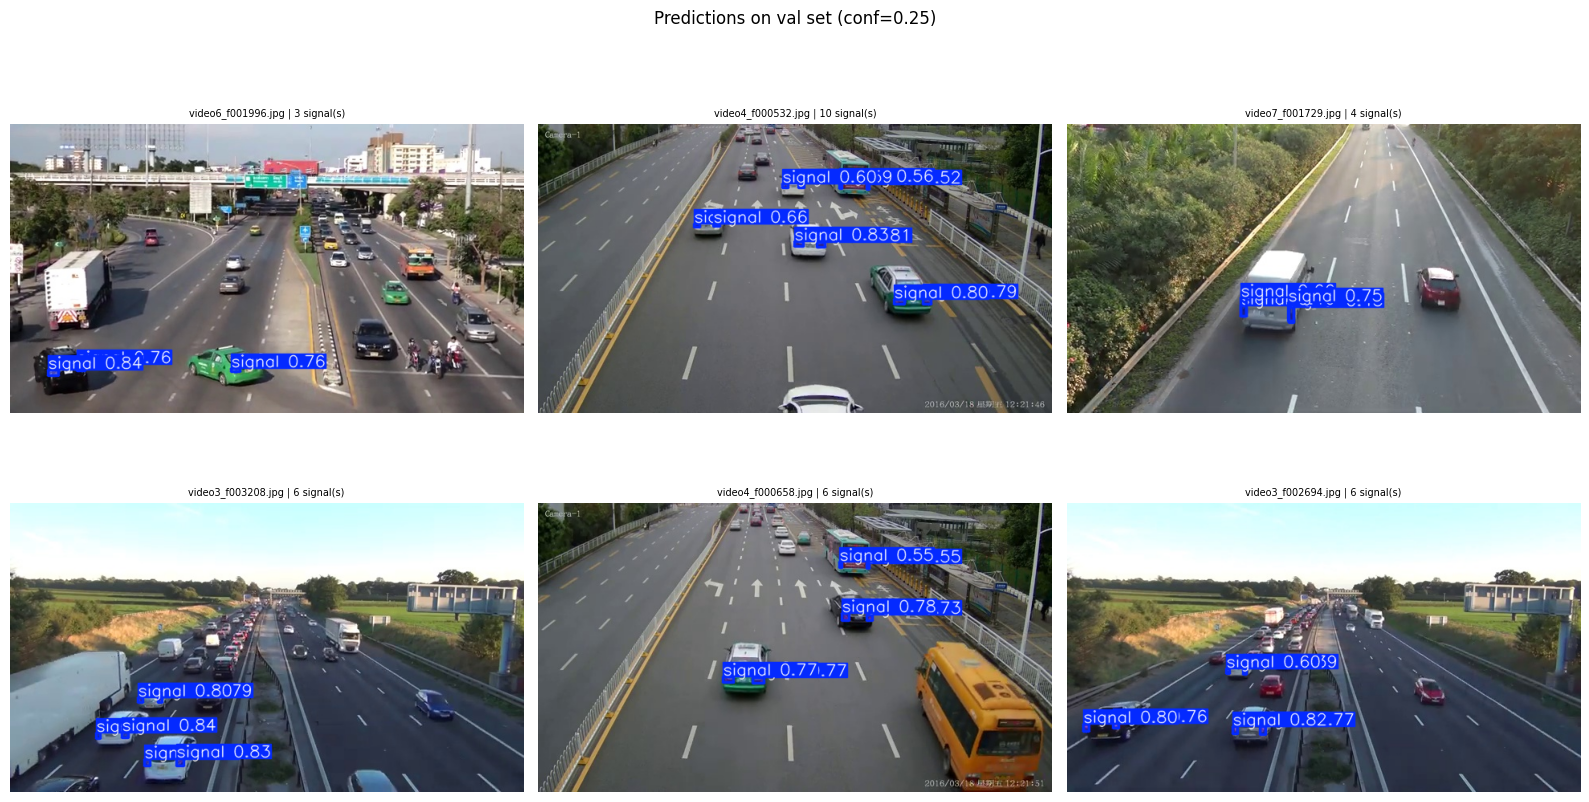

In [20]:
import cv2, random, matplotlib.pyplot as plt

val_img_dir = f'{BASE}/images/val'
val_imgs    = os.listdir(val_img_dir)
samples     = random.sample(val_imgs, min(6, len(val_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, fname in zip(axes.flat, samples):
    res  = model_val.predict(f'{val_img_dir}/{fname}', conf=0.25, imgsz=1280, verbose=False)[0]
    plot = res.plot()
    ax.imshow(cv2.cvtColor(plot, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{fname} | {len(res.boxes)} signal(s)', fontsize=7)
    ax.axis('off')

plt.suptitle('Predictions on val set (conf=0.25)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/val_predictions.png', dpi=100)
plt.show()

In [21]:
import time, cv2

img = cv2.imread(f'{val_img_dir}/{val_imgs[0]}')
for _ in range(3):
    model_val.predict(img, conf=0.25, imgsz=1280, verbose=False)

N  = 20
t0 = time.perf_counter()
for _ in range(N):
    model_val.predict(img, conf=0.25, imgsz=1280, verbose=False)
elapsed = time.perf_counter() - t0

print(f'Speed (imgsz=1280): {elapsed/N*1000:.1f} ms/frame | {N/elapsed:.1f} FPS')

Speed (imgsz=1280): 34.7 ms/frame | 28.8 FPS


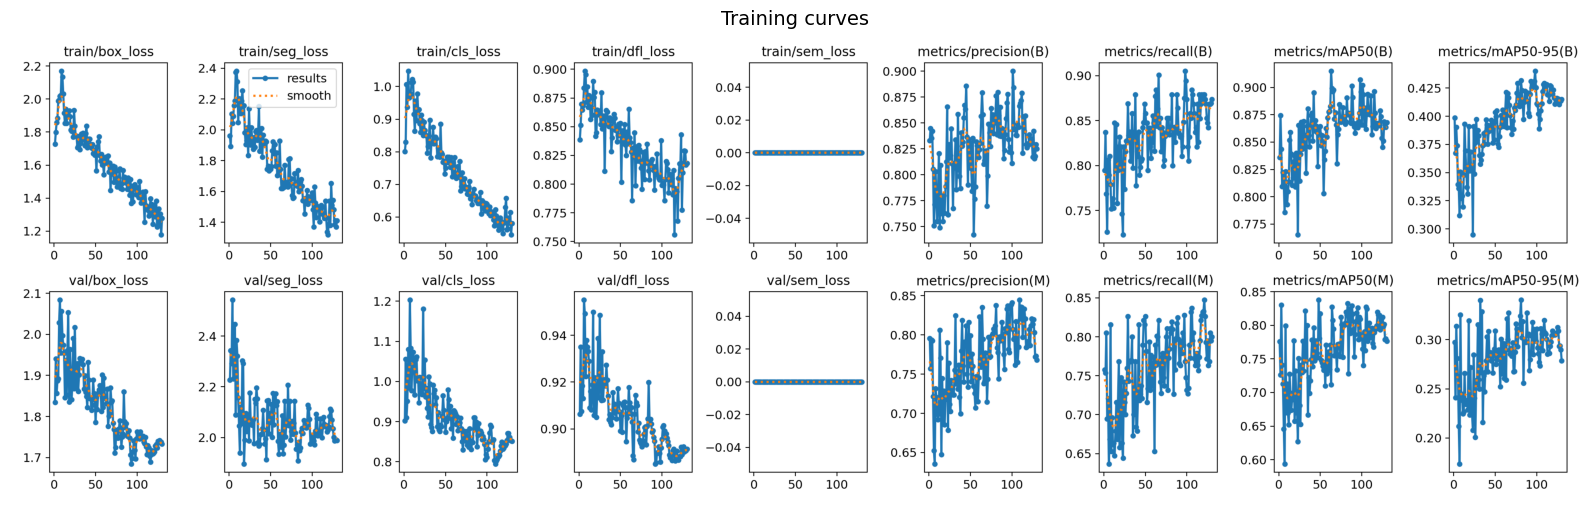

In [22]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg

curve_png = f'{WORK_DIR}/runs/segment/{RUN_NAME}/results.png'
if os.path.exists(curve_png):
    img = mpimg.imread(curve_png)
    plt.figure(figsize=(16, 8))
    plt.imshow(img); plt.axis('off')
    plt.title('Training curves', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{WORK_DIR}/training_curves.png', dpi=100)
    plt.show()
else:
    print('results.png not found')

In [19]:
import shutil

best_pt = f'{WORK_DIR}/runs/segment/{RUN_NAME}/weights/best.pt'
dst     = f'{WORK_DIR}/best_signal_seg.pt'
shutil.copy(best_pt, dst)

size_mb = os.path.getsize(dst) / 1e6
print(f'Saved: {dst}  ({size_mb:.1f} MB)')
print('Download and put in project folder as: best_signal_seg.pt')

Saved: /kaggle/working/best_signal_seg.pt  (23.9 MB)
Download and put in project folder as: best_signal_seg.pt
